In [1]:
import rasterio
import numpy as np
import os
import matplotlib.pyplot as plt
import hashlib
import pandas as pd

from tqdm import tqdm
from xgboost import XGBClassifier
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split
from scipy.ndimage import uniform_filter
from sklearn.metrics import classification_report, confusion_matrix, jaccard_score

In [ ]:
CLASS_NAMES = {
    0: "Unknown",
    1: "Greenery",
    2: "Sand",
    3: "Water",
    4: "Cement",
}

TRAIN_SAMPLES = 600_000
VAL_SAMPLES = 500_000
RANDOM_STATE = 42

In [3]:
def preprocess_img(img_path, mask_path):
    with rasterio.open(img_path) as src:
        img = src.read().astype(np.float32)

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    img = np.clip(img, 0, 10000) / 10000.0
    return img, mask

In [4]:
def local_mean_std(x, size=3):
    mean = uniform_filter(x, size=size, mode="reflect")
    mean_sq = uniform_filter(x * x, size=size, mode="reflect")
    var = np.maximum(mean_sq - mean * mean, 0.0)
    std = np.sqrt(var)
    return mean, std

def local_range(x, size=3):
    pad = size // 2
    xp = np.pad(x, pad, mode="reflect")
    h, w = x.shape
    out = np.empty((h, w), dtype=np.float32)
    for i in range(h):
        for j in range(w):
            patch = xp[i:i+size, j:j+size]
            out[i, j] = patch.max() - patch.min()
    return out

def gradient_mag(x):
    gx = np.gradient(x, axis=1)
    gy = np.gradient(x, axis=0)
    return np.sqrt(gx * gx + gy * gy).astype(np.float32)

def normalized_diff(a, b, eps=1e-6):
    return (a - b) / (a + b + eps)

def ratio(a, b, eps=1e-6):
    return a / (b + eps)

def extract_features(img):
    b = img.astype(np.float32)

    blue  = b[1]
    green = b[2]
    red   = b[3]
    nir   = b[7]
    swir1 = b[10]
    swir2 = b[11]

    ndvi = normalized_diff(nir, red)
    ndwi = normalized_diff(green, nir)
    mndwi = normalized_diff(green, swir1)
    ndbi = normalized_diff(swir1, nir)
    ui = normalized_diff(swir2, nir)
    ndmi = normalized_diff(nir, swir1)
    bsi = ((swir1 + red) - (nir + blue)) / ((swir1 + red) + (nir + blue) + 1e-6)
    swir_ratio = ratio(swir1, swir2)
    red_swir_ratio = ratio(red, swir1)
    cement_score = ndbi + ui + bsi - ndvi - mndwi
    ndvi_mean, ndvi_std = local_mean_std(ndvi, size=3)
    ndbi_mean, ndbi_std = local_mean_std(ndbi, size=3)
    bsi_mean, bsi_std = local_mean_std(bsi, size=3)
    cement_mean, cement_std = local_mean_std(cement_score, size=3)
    red_mean, red_std = local_mean_std(red, size=3)
    nir_mean, nir_std = local_mean_std(nir, size=3)
    swir1_mean, swir1_std = local_mean_std(swir1, size=3)
    swir2_mean, swir2_std = local_mean_std(swir2, size=3)
    red_grad = gradient_mag(red)
    nir_grad = gradient_mag(nir)
    swir1_grad = gradient_mag(swir1)
    cement_grad = gradient_mag(cement_score)
    red_range_3 = local_range(red, size=3)
    swir1_range_3 = local_range(swir1, size=3)
    cement_range_3 = local_range(cement_score, size=3)
    features = np.concatenate(
        [
            b,
            ndvi[np.newaxis, ...],
            ndwi[np.newaxis, ...],
            mndwi[np.newaxis, ...],
            ndbi[np.newaxis, ...],
            ui[np.newaxis, ...],
            ndmi[np.newaxis, ...],
            bsi[np.newaxis, ...],
            swir_ratio[np.newaxis, ...],
            red_swir_ratio[np.newaxis, ...],
            cement_score[np.newaxis, ...],
            ndvi_mean[np.newaxis, ...],
            ndvi_std[np.newaxis, ...],
            ndbi_mean[np.newaxis, ...],
            ndbi_std[np.newaxis, ...],
            bsi_mean[np.newaxis, ...],
            bsi_std[np.newaxis, ...],
            cement_mean[np.newaxis, ...],
            cement_std[np.newaxis, ...],
            red_mean[np.newaxis, ...],
            red_std[np.newaxis, ...],
            nir_mean[np.newaxis, ...],
            nir_std[np.newaxis, ...],
            swir1_mean[np.newaxis, ...],
            swir1_std[np.newaxis, ...],
            swir2_mean[np.newaxis, ...],
            swir2_std[np.newaxis, ...],
            red_grad[np.newaxis, ...],
            nir_grad[np.newaxis, ...],
            swir1_grad[np.newaxis, ...],
            cement_grad[np.newaxis, ...],
            red_range_3[np.newaxis, ...],
            swir1_range_3[np.newaxis, ...],
            cement_range_3[np.newaxis, ...],
        ],
        axis=0,
    )

    feature_names = [f"B{i + 1}" for i in range(b.shape[0])] + [
        "ndvi",
        "ndwi",
        "mndwi",
        "ndbi",
        "ui",
        "ndmi",
        "bsi",
        "swir_ratio",
        "red_swir_ratio",
        "cement_score",
        "ndvi_mean_3",
        "ndvi_std_3",
        "ndbi_mean_3",
        "ndbi_std_3",
        "bsi_mean_3",
        "bsi_std_3",
        "cement_mean_3",
        "cement_std_3",
        "red_mean_3",
        "red_std_3",
        "nir_mean_3",
        "nir_std_3",
        "swir1_mean_3",
        "swir1_std_3",
        "swir2_mean_3",
        "swir2_std_3",
        "red_grad",
        "nir_grad",
        "swir1_grad",
        "cement_grad",
        "red_range_3",
        "swir1_range_3",
        "cement_range_3",
    ]

    return features, feature_names

In [5]:
def count_by_class(y):
    classes, counts = np.unique(y, return_counts=True)
    return {int(cls): int(count) for cls, count in zip(classes, counts)}


def compute_balanced_targets(y, total_samples, allow_replacement=False):
    classes = sorted(int(cls) for cls in np.unique(y))
    total_samples = int(total_samples)
    base = total_samples // len(classes)
    remainder = total_samples % len(classes)

    targets = {}
    availability = count_by_class(y)

    for i, cls in enumerate(classes):
        target = base + (1 if i < remainder else 0)
        if not allow_replacement:
            target = min(target, availability[cls])
        targets[cls] = int(target)

    if not allow_replacement:
        shortfall = total_samples - sum(targets.values())
        if shortfall > 0:
            remaining = {
                cls: availability[cls] - targets[cls]
                for cls in classes
            }
            active = [cls for cls in classes if remaining[cls] > 0]

            while active and shortfall > 0:
                share = max(1, shortfall // len(active))
                for cls in list(active):
                    take = min(share, remaining[cls], shortfall)
                    targets[cls] += take
                    remaining[cls] -= take
                    shortfall -= take
                    if remaining[cls] == 0:
                        active.remove(cls)
                    if shortfall == 0:
                        break

    return targets


def sample_balanced_subset(X, y, total_samples, random_state=42, allow_replacement=False):
    rng = np.random.RandomState(random_state)
    targets = compute_balanced_targets(
        y,
        total_samples=total_samples,
        allow_replacement=allow_replacement,
    )
    sampled_indices = []
    availability = count_by_class(y)
    replacement_used = {}

    for cls in sorted(targets):
        cls_indices = np.where(y == cls)[0]
        take = targets[cls]
        replace = allow_replacement and take > len(cls_indices)
        chosen = rng.choice(cls_indices, size=take, replace=replace)
        sampled_indices.append(chosen)
        replacement_used[int(cls)] = replace

    sampled_indices = np.concatenate(sampled_indices)
    rng.shuffle(sampled_indices)

    return (
        X[sampled_indices],
        y[sampled_indices],
        targets,
        availability,
        replacement_used,
    )

In [6]:
def plot_class_distribution(y, title):
    classes, counts = np.unique(y, return_counts=True)
    labels = [f"{int(cls)} - {CLASS_NAMES.get(int(cls), f'Class {int(cls)}')}" for cls in classes]

    plt.figure(figsize=(8, 4))
    bars = plt.bar(
        labels,
        counts,
        color=["#4CAF50", "#D2B48C", "#1E88E5", "#9E9E9E"][: len(labels)],
    )
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Pixel count")
    plt.grid(axis="y", linestyle="--", alpha=0.3)

    for bar, count in zip(bars, counts):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            count,
            f"{int(count):,}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()


def print_sampling_summary(name, sampled_y, targets, availability, replacement_used):
    print(f"{name} availability:", availability)
    print(f"{name} targets:", targets)
    print(f"{name} sampled counts:", count_by_class(sampled_y))
    print(f"{name} replacement used:", replacement_used)

In [7]:
def process_pair(img_path, mask_path):
    img, mask = preprocess_img(img_path, mask_path)
    feats, feature_names = extract_features(img)

    X = feats.reshape(feats.shape[0], -1).T
    y = mask.reshape(-1)

    return X, y, feature_names


def build_dataset(img_paths, mask_paths, n_jobs=4):
    pairs = list(zip(img_paths, mask_paths))
    total = len(pairs)

    results = Parallel(n_jobs=n_jobs, backend="loky")(
        delayed(process_pair)(img_path, mask_path)
        for img_path, mask_path in tqdm(pairs, desc="Processing images")
    )

    X_list = []
    y_list = []
    feature_names = None

    for i, (X, y, names) in enumerate(results, 1):
        X_list.append(X)
        y_list.append(y)

        if feature_names is None:
            feature_names = names

        print(f"Finished {i}/{total} | Remaining: {total - i}")

    X_all = np.concatenate(X_list, axis=0)
    y_all = np.concatenate(y_list, axis=0)

    return X_all, y_all, feature_names

In [ ]:
imgs = sorted(
    [
        os.path.join("./data", f"imgs/{img}")
        for img in os.listdir("./data/imgs")
        if img.endswith(".tif")
    ]
)
masks = sorted(
    [
        os.path.join("./data", f"masks/{mask}")
        for mask in os.listdir("./data/masks")
        if mask.endswith(".tif")
    ]
)

print(len(imgs))
print(len(masks))

X_train, X_val, y_train, y_val = train_test_split(
    imgs,
    masks,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

X_val, y_val, X_test, y_test = train_test_split(
    X_val, y_val, test_size=0.5, random_state=RANDOM_STATE
)

Xtr, ytr, feature_names = build_dataset(X_train, y_train, n_jobs=-1)
Xva, yva, _ = build_dataset(X_val, y_val, n_jobs=-1)
Xte, yte, _ = build_dataset(X_test, y_test, n_jobs=-1)

print("Train:", Xtr.shape, ytr.shape)
print("Val  :", Xva.shape, yva.shape)
print("Test :", Xte.shape, yte.shape)

365
365


Processing images: 100%|██████████| 255/255 [00:13<00:00, 19.61it/s]


Finished 1/255 | Remaining: 254
Finished 2/255 | Remaining: 253
Finished 3/255 | Remaining: 252
Finished 4/255 | Remaining: 251
Finished 5/255 | Remaining: 250
Finished 6/255 | Remaining: 249
Finished 7/255 | Remaining: 248
Finished 8/255 | Remaining: 247
Finished 9/255 | Remaining: 246
Finished 10/255 | Remaining: 245
Finished 11/255 | Remaining: 244
Finished 12/255 | Remaining: 243
Finished 13/255 | Remaining: 242
Finished 14/255 | Remaining: 241
Finished 15/255 | Remaining: 240
Finished 16/255 | Remaining: 239
Finished 17/255 | Remaining: 238
Finished 18/255 | Remaining: 237
Finished 19/255 | Remaining: 236
Finished 20/255 | Remaining: 235
Finished 21/255 | Remaining: 234
Finished 22/255 | Remaining: 233
Finished 23/255 | Remaining: 232
Finished 24/255 | Remaining: 231
Finished 25/255 | Remaining: 230
Finished 26/255 | Remaining: 229
Finished 27/255 | Remaining: 228
Finished 28/255 | Remaining: 227
Finished 29/255 | Remaining: 226
Finished 30/255 | Remaining: 225
Finished 31/255 | R

Processing images: 100%|██████████| 110/110 [00:04<00:00, 26.89it/s]


Finished 1/110 | Remaining: 109
Finished 2/110 | Remaining: 108
Finished 3/110 | Remaining: 107
Finished 4/110 | Remaining: 106
Finished 5/110 | Remaining: 105
Finished 6/110 | Remaining: 104
Finished 7/110 | Remaining: 103
Finished 8/110 | Remaining: 102
Finished 9/110 | Remaining: 101
Finished 10/110 | Remaining: 100
Finished 11/110 | Remaining: 99
Finished 12/110 | Remaining: 98
Finished 13/110 | Remaining: 97
Finished 14/110 | Remaining: 96
Finished 15/110 | Remaining: 95
Finished 16/110 | Remaining: 94
Finished 17/110 | Remaining: 93
Finished 18/110 | Remaining: 92
Finished 19/110 | Remaining: 91
Finished 20/110 | Remaining: 90
Finished 21/110 | Remaining: 89
Finished 22/110 | Remaining: 88
Finished 23/110 | Remaining: 87
Finished 24/110 | Remaining: 86
Finished 25/110 | Remaining: 85
Finished 26/110 | Remaining: 84
Finished 27/110 | Remaining: 83
Finished 28/110 | Remaining: 82
Finished 29/110 | Remaining: 81
Finished 30/110 | Remaining: 80
Finished 31/110 | Remaining: 79
Finishe

In [11]:
def sample_feature_frame(X, y, feature_names, classes=(2, 4), n_per_class=40000, random_state=42):
    rng = np.random.RandomState(random_state)
    frames = []

    for cls in classes:
        idx = np.where(y == cls)[0]
        take = min(n_per_class, len(idx))
        chosen = rng.choice(idx, size=take, replace=False)
        frame = pd.DataFrame(X[chosen], columns=feature_names)
        frame["label"] = cls
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


def rank_feature_gaps(df, features, class_a=2, class_b=4):
    means = df.groupby("label")[features].mean()
    stds = df.groupby("label")[features].std()
    return pd.DataFrame(
        {
            "mean_class_2": means.loc[class_a],
            "mean_class_4": means.loc[class_b],
            "std_class_2": stds.loc[class_a],
            "std_class_4": stds.loc[class_b],
            "abs_mean_gap": (means.loc[class_a] - means.loc[class_b]).abs(),
        }
    ).sort_values("abs_mean_gap", ascending=False)


def plot_feature_histograms(df, features):
    fig, axes = plt.subplots(len(features), 1, figsize=(8, 3 * len(features)))
    if len(features) == 1:
        axes = [axes]

    colors = {2: "#D2B48C", 4: "#6E6E6E"}

    for ax, feature in zip(axes, features):
        for cls in [2, 4]:
            values = df.loc[df["label"] == cls, feature].values
            ax.hist(values, bins=50, alpha=0.45, density=True, color=colors[cls], label=CLASS_NAMES[cls])
        ax.set_title(feature)
        ax.grid(alpha=0.2)
        ax.legend()

    plt.tight_layout()
    plt.show()


def plot_feature_correlation(df, features, title):
    corr = df[features].corr().values
    plt.figure(figsize=(9, 7))
    plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
    plt.xticks(range(len(features)), features, rotation=45, ha="right")
    plt.yticks(range(len(features)), features)
    plt.title(title)
    plt.colorbar(label="Correlation")
    plt.tight_layout()
    plt.show()


In [12]:
def get_feature_index(feature_names):
    return {name: idx for idx, name in enumerate(feature_names)}


def zero_signal_mask(X, feature_names, eps=1e-8):
    idx = get_feature_index(feature_names)
    band_cols = [idx[f"B{i}"] for i in range(1, 13)]
    band_block = X[:, band_cols]
    return np.all(np.abs(band_block) <= eps, axis=1)


def print_zero_signal_summary(X, y, feature_names, name):
    mask = zero_signal_mask(X, feature_names)
    print(f"{name} zero-signal labeled pixels: {int(mask.sum()):,} / {len(mask):,} ({mask.mean():.4%})")
    if mask.any():
        vals, cnts = np.unique(y[mask], return_counts=True)
        print(
            f"{name} zero-signal per class:",
            {CLASS_NAMES.get(int(v), f"Class_{int(v)}"): int(c) for v, c in zip(vals, cnts)},
        )
    return mask


def stabilize_features(X, feature_names):
    Xs = X.copy()
    idx = get_feature_index(feature_names)

    clip_ranges = {
        "ndvi": (-1, 1),
        "ndwi": (-1, 1),
        "mndwi": (-1, 1),
        "ndbi": (-1, 1),
        "ui": (-1, 1),
        "ndmi": (-1, 1),
        "bsi": (-1, 1),

        "swir_ratio": (0, 5),
        "red_swir_ratio": (0, 5),

        "cement_score": (-2, 2),
        "cement_mean_3": (-2, 2),
        "cement_std_3": (0, 2),

        "bsi_mean_3": (-1, 1),
        "bsi_std_3": (0, 1),
        "ndbi_mean_3": (-1, 1),
        "ndbi_std_3": (0, 1),
        "ndvi_mean_3": (-1, 1),
        "ndvi_std_3": (0, 1),

        "red_mean_3": (0, 1),
        "red_std_3": (0, 1),
        "nir_mean_3": (0, 1),
        "nir_std_3": (0, 1),
        "swir1_mean_3": (0, 1),
        "swir1_std_3": (0, 1),
        "swir2_mean_3": (0, 1),
        "swir2_std_3": (0, 1),

        "red_grad": (0, 1),
        "nir_grad": (0, 1),
        "swir1_grad": (0, 1),
        "cement_grad": (0, 2),

        "red_range_3": (0, 1),
        "swir1_range_3": (0, 1),
        "cement_range_3": (0, 2),
    }

    for name, (lo, hi) in clip_ranges.items():
        if name in idx:
            col = idx[name]
            Xs[:, col] = np.clip(Xs[:, col], lo, hi)

    return Xs


def remove_zero_signal_rows(X, y, feature_names):
    keep = ~zero_signal_mask(X, feature_names)
    return X[keep], y[keep], keep

In [ ]:
train_zero_mask = print_zero_signal_summary(Xtr, ytr, feature_names, "Train")
val_zero_mask = print_zero_signal_summary(Xva, yva, feature_names, "Validation")
test_zero_mask = print_zero_signal_summary(Xte, yte, feature_names, "Test")
Xtr_clean, ytr_clean, train_keep = remove_zero_signal_rows(Xtr, ytr, feature_names)
Xva_clean, yva_clean, val_keep = remove_zero_signal_rows(Xva, yva, feature_names)
Xte_clean, yte_clean, test_keep = remove_zero_signal_rows(Xte, yte, feature_names)
Xtr_clean = stabilize_features(Xtr_clean, feature_names)
Xva_clean = stabilize_features(Xva_clean, feature_names)
Xte_clean = stabilize_features(Xte_clean, feature_names)
train_valid = ytr_clean != 0
val_valid = yva_clean != 0
test_valid = yte_clean != 0

Xtr_clean = Xtr_clean[train_valid]
ytr_clean = ytr_clean[train_valid]
Xva_clean = Xva_clean[val_valid]
yva_clean = yva_clean[val_valid]
Xte_clean = Xte_clean[test_valid]
yte_clean = yte_clean[test_valid]

Xva_clean, yva_clean, _, _, _ = sample_balanced_subset(
    Xva_clean,
    yva_clean,
    total_samples=VAL_SAMPLES,
    random_state=RANDOM_STATE,
)

print("After zero-signal filtering + removing class 0 + balanced val subset:")
print("Train:", Xtr_clean.shape, ytr_clean.shape)
print("Val  :", Xva_clean.shape, yva_clean.shape)
print("Test :", Xte_clean.shape, yte_clean.shape)
print("Train class counts:", count_by_class(ytr_clean))
print("Val class counts:", count_by_class(yva_clean))
print("Test class counts:", count_by_class(yte_clean))

Train zero-signal labeled pixels: 59,833 / 16,711,680 (0.3580%)
Train zero-signal per class: {'Unknown': 7308, 'Greenery': 1125, 'Sand': 51392, 'Cement': 8}
Validation zero-signal labeled pixels: 61,720 / 7,208,960 (0.8562%)
Validation zero-signal per class: {'Unknown': 1537, 'Greenery': 283, 'Sand': 59892, 'Cement': 8}
After zero-signal filtering + removing class 0 + balanced val subset:
Train: (9861716, 45) (9861716,)
Val  : (500000, 45) (500000,)
Train class counts: {1: 7073551, 2: 2414576, 3: 201471, 4: 172118}
Val class counts: {1: 189992, 2: 189992, 3: 45872, 4: 74144}


,mean_class_2,mean_class_4,std_class_2,std_class_4,abs_mean_gap
cement_range_3,0.129872,0.474781,0.118248,0.294973,0.344909
cement_mean_3,0.706937,0.368058,0.164423,0.338141,0.338879
cement_score,0.707092,0.377820,0.173288,0.365526,0.329272
swir1_mean_3,0.539314,0.293744,0.147418,0.074333,0.245570
B11,0.539464,0.294246,0.147626,0.075429,0.245217
swir2_mean_3,0.488426,0.258378,0.137586,0.078930,0.230047
B12,0.488575,0.259133,0.137896,0.080234,0.229442
red_mean_3,0.348430,0.174410,0.094454,0.057507,0.174020
nir_mean_3,0.420260,0.254121,0.116340,0.046547,0.166139
cement_grad,0.042739,0.162797,0.046476,0.127934,0.120058


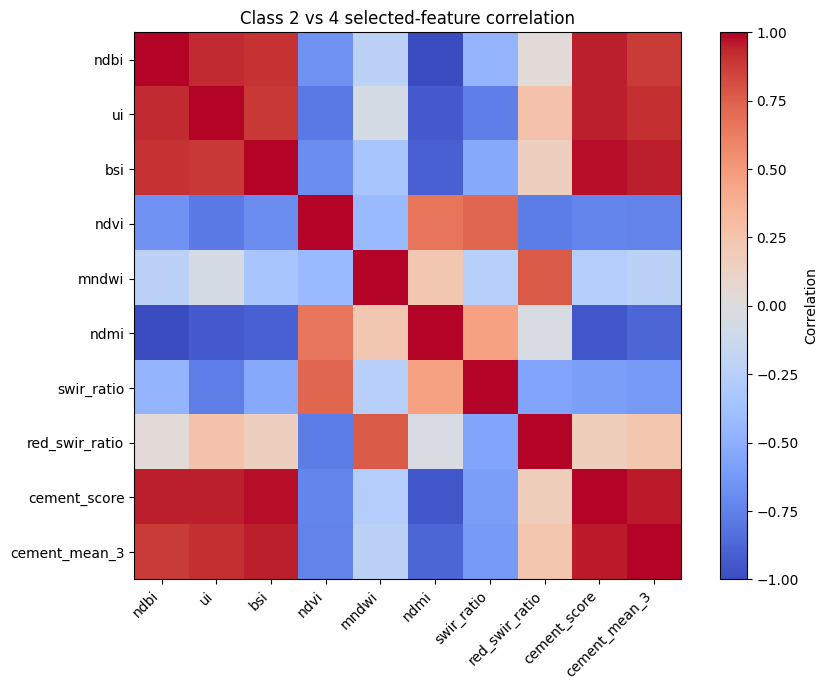

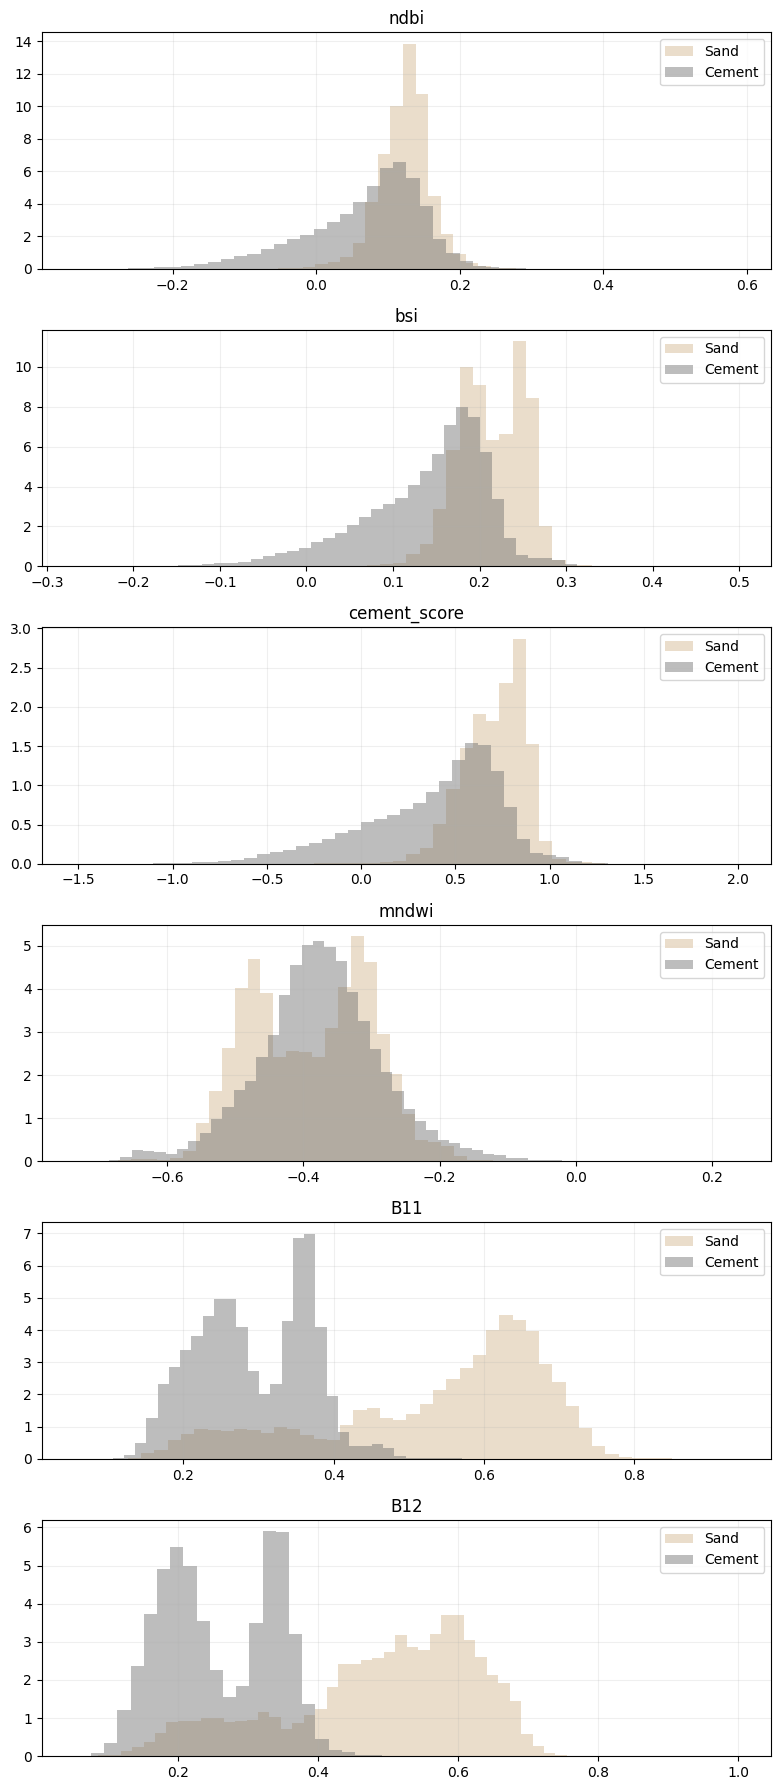

In [14]:
cement_features = [
    "ndbi",
    "ui",
    "bsi",
    "ndvi",
    "mndwi",
    "ndmi",
    "swir_ratio",
    "red_swir_ratio",
    "cement_score",
    "cement_mean_3",
    "cement_std_3",
    "bsi_mean_3",
    "bsi_std_3",
    "ndbi_mean_3",
    "ndbi_std_3",
    "red_mean_3",
    "red_std_3",
    "nir_mean_3",
    "nir_std_3",
    "swir1_mean_3",
    "swir1_std_3",
    "swir2_mean_3",
    "swir2_std_3",
    "red_grad",
    "nir_grad",
    "swir1_grad",
    "cement_grad",
    "red_range_3",
    "swir1_range_3",
    "cement_range_3",
    "B11",
    "B12",
]

feature_probe_df = sample_feature_frame(
    Xtr_clean,
    ytr_clean,
    feature_names,
    classes=(2, 4),
    n_per_class=40000,
    random_state=RANDOM_STATE,
)

display(rank_feature_gaps(feature_probe_df, cement_features).head(15))
plot_feature_correlation(feature_probe_df, cement_features[:10], "Class 2 vs 4 selected-feature correlation")
plot_feature_histograms(feature_probe_df, ["ndbi", "bsi", "cement_score", "mndwi", "B11", "B12"])

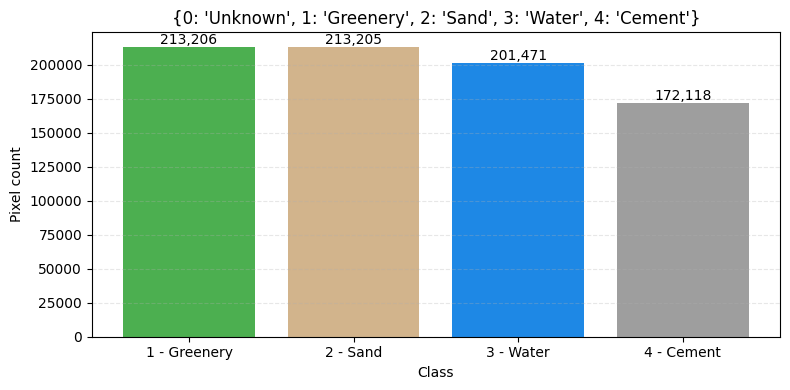

[[0.04995    0.06585    0.10465    ... 0.0501     0.02155    0.16987538]
 [0.0604     0.06645    0.0991     ... 0.0686     0.01965001 0.12604415]
 [0.05725    0.0536     0.0429     ... 0.00255    0.0008     0.15528786]
 ...
 [0.0337     0.042      0.064      ... 0.0068     0.00839999 0.3246374 ]
 [0.05975    0.05945    0.045      ... 0.00575    0.0036     0.35309786]
 [0.15945    0.2012     0.3036     ... 0.00750002 0.01500005 0.03986764]] availability: {1: 7073551, 2: 2414576, 3: 201471, 4: 172118}
[[0.04995    0.06585    0.10465    ... 0.0501     0.02155    0.16987538]
 [0.0604     0.06645    0.0991     ... 0.0686     0.01965001 0.12604415]
 [0.05725    0.0536     0.0429     ... 0.00255    0.0008     0.15528786]
 ...
 [0.0337     0.042      0.064      ... 0.0068     0.00839999 0.3246374 ]
 [0.05975    0.05945    0.045      ... 0.00575    0.0036     0.35309786]
 [0.15945    0.2012     0.3036     ... 0.00750002 0.01500005 0.03986764]] targets: {1: 213206, 2: 213205, 3: 201471, 4: 17211

In [ ]:
train_mask = np.isin(ytr_clean, [1, 2, 3, 4])
val_mask = np.isin(yva_clean, [1, 2, 3, 4])
test_mask = np.isin(yte_clean, [1, 2, 3, 4])

X_train_mc = Xtr_clean[train_mask]
y_train_mc = ytr_clean[train_mask]
X_val_mc = Xva_clean[val_mask]
y_val_mc = yva_clean[val_mask]
X_test_mc = Xte_clean[test_mask]
y_test_mc = yte_clean[test_mask]

X_train_mc_s, y_train_mc_s, targets_mc, availability_mc, replacement_mc = sample_balanced_subset(
    X_train_mc,
    y_train_mc,
    total_samples=TRAIN_SAMPLES,
    random_state=RANDOM_STATE,
    allow_replacement=False,
)

plot_class_distribution(y_train_mc_s, CLASS_NAMES)
print_sampling_summary(X_train_mc_s, y_train_mc_s, targets_mc, availability_mc, replacement_mc)

In [ ]:
label_to_xgb = {1: 0, 2: 1, 3: 2, 4: 3}
xgb_to_label = {0: 1, 1: 2, 2: 3, 3: 4}
y_train_mc = np.array([label_to_xgb[int(v)] for v in y_train_mc_s], dtype=np.uint8)
sample_weights = np.where(y_train_mc_s == 4, 3.0, 1.0).astype(np.float32)
direct = XGBClassifier(
    n_estimators=900,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.2,
    reg_lambda=2.0,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
direct.fit(X_train_mc_s, y_train_mc, sample_weight=sample_weights)

cement_boost = 1.15
print("============== Validation set ==============")
y_prob_mc = direct.predict_proba(X_val_mc)
y_prob_mc[:, 3] *= cement_boost
y_prob_mc = y_prob_mc / y_prob_mc.sum(axis=1, keepdims=True)
y_pred_mc = np.argmax(y_prob_mc, axis=1)
y_pred_mc = np.array([xgb_to_label[int(v)] for v in y_pred_mc], dtype=np.uint8)
print("Direct XGBoost on cleaned data")
print(classification_report(y_val_mc, y_pred_mc, digits=4, labels=[1, 2, 3, 4]))
cm_mc = confusion_matrix(y_val_mc, y_pred_mc, labels=[1, 2, 3, 4])
print("Confusion Matrix:\n", cm_mc)
macro_iou_mc = jaccard_score(y_val_mc, y_pred_mc, average="macro", labels=[1, 2, 3, 4])
per_class_iou_mc = jaccard_score(y_val_mc, y_pred_mc, average=None, labels=[1, 2, 3, 4])
print("mIoU:", macro_iou_mc)
print(
    "Per-class IoU:",
    {CLASS_NAMES[cls]: float(score) for cls, score in zip([1, 2, 3, 4], per_class_iou_mc)},
)
print("Direct multiclass feature importances:")
importances = sorted(
    zip(feature_names, direct.feature_importances_),
    key=lambda item: item[1],
    reverse=True,
)
for name, score in importances[:20]:
    print(f"  {name}: {score:.5f}")


Direct XGBoost on cleaned data
              precision    recall  f1-score   support

           1     0.9191    0.9394    0.9291    189992
           2     0.8614    0.9726    0.9136    189992
           3     0.9833    0.9872    0.9852     45872
           4     0.7851    0.4790    0.5950     74144

    accuracy                         0.8881    500000
   macro avg     0.8872    0.8445    0.8557    500000
weighted avg     0.8832    0.8881    0.8788    500000

Confusion Matrix:
 [[178471   5208    135   6178]
 [  1416 184789    364   3423]
 [    64    404  45285    119]
 [ 14234  24124    272  35514]]
mIoU: 0.7757371611423778
Per-class IoU: {'Greenery': 0.8676023062039999, 'Sand': 0.8409897691691546, 'Water': 0.9708852346547178, 'Cement': 0.4234713345416388}
Direct multiclass feature importances:
  swir1_mean_3: 0.25539
  red_swir_ratio: 0.12960
  swir2_mean_3: 0.09548
  red_range_3: 0.09302
  red_mean_3: 0.07999
  ndvi_std_3: 0.04194
  B11: 0.04147
  red_std_3: 0.02795
  mndwi: 0.024

In [ ]:
# print("============== Test set ==============")
# y_prob_mc = direct.predict_proba(X_test_mc)
# cement_boost = 1.15
# y_prob_mc[:, 3] *= cement_boost
# y_prob_mc = y_prob_mc / y_prob_mc.sum(axis=1, keepdims=True)
# y_pred_mc = np.argmax(y_prob_mc, axis=1)
# y_pred_mc = np.array([xgb_to_label[int(v)] for v in y_pred_mc], dtype=np.uint8)
# print("Direct XGBoost on cleaned data")
# print(classification_report(y_test_mc, y_pred_mc, digits=4, labels=[1, 2, 3, 4]))
# cm_mc = confusion_matrix(y_test_mc, y_pred_mc, labels=[1, 2, 3, 4])
# print("Confusion Matrix:\n", cm_mc)
# macro_iou_mc = jaccard_score(y_test_mc, y_pred_mc, average="macro", labels=[1, 2, 3, 4])
# per_class_iou_mc = jaccard_score(y_test_mc, y_pred_mc, average=None, labels=[1, 2, 3, 4])
# print("mIoU:", macro_iou_mc)
# print(
#     "Per-class IoU:",
#     {CLASS_NAMES[cls]: float(score) for cls, score in zip([1, 2, 3, 4], per_class_iou_mc)},
# )
# print("Direct multiclass feature importances:")
# importances = sorted(
#     zip(feature_names, direct.feature_importances_),
#     key=lambda item: item[1],
#     reverse=True,
# )
# for name, score in importances[:20]:
#     print(f"  {name}: {score:.5f}")
